# Deterministic Acceptance-Rejection Sampling in QMC.jl

This notebook mirrors the QMCPy `acceptance_rejection.ipynb` demo while using the Julia `QMC.jl` APIs. It demonstrates the `AcceptanceRejection` and `AcceptanceRejectionReal` true measures, which implement Algorithms 2 and 3 from Zhu and Dick (2014). Replacing the standard random driver with a low-discrepancy sequence improves the convergence rate of the accepted samples from $O(N^{-1/2})$ to $O(N^{-1/s})$, where $s = d + 1$ is the driver dimension.

Original QMCPy demo: [`QMCPy/demos/acceptance_rejection.ipynb`](../../QMCPy/demos/acceptance_rejection.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/acceptance_rejection.ipynb)

Parity note: QMCPy exposes deterministic acceptance-rejection through `gen_samples(n / n_min / n_max)` on accepted samples, while QMC.jl exposes the same algorithms as a true-measure `transform` over a proposal window. This notebook preserves the same algorithms, seeds, continued-sampling discussion, and final star-discrepancy comparison while documenting the Julia proposal-window API and its batch semantics.


**Reference:** Zhu, H. & Dick, J. (2014). *Discrepancy bounds for deterministic acceptance-rejection samplers.* Electronic Journal of Statistics, 8(1), 678–707. [DOI: 10.1214/14-EJS898](https://doi.org/10.1214/14-EJS898)

## Setup

## Background

Standard acceptance-rejection sampling draws a proposal point $x$ and an auxiliary uniform threshold $u \sim \mathcal{U}[0,1]$. The candidate is accepted when

$$\psi(x) \geq Lu,$$

where $\psi$ is the target density and $L$ is a known upper bound. The key idea in the QMCPy and QMC.jl demos is to replace the IID driver with a low-discrepancy point set in dimension $d + 1$, so that the accepted samples inherit better discrepancy properties than ordinary Monte Carlo samples.


In [1]:
using QMC
using Statistics
using Printf
using Distributions: Normal, pdf, quantile

function accepted_from_proposals(tm; proposal_start::Int = 0, proposal_count::Int)
    x = gen_samples(tm.dd, proposal_count; n_start = proposal_start)
    return transform(tm, x)
end

# Plots.jl is optional; guard plot cells so the notebook runs in headless CI.
const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## Algorithm 2 - DAR on $[0,1]^d$

For a density $\psi : [0,1]^d \to \mathbb{R}_+$, the driver is a $(t,m,s)$-net in $s = d + 1$ dimensions. Each driver point

$$q = (x_1, \ldots, x_d, u) \in [0,1]^{d+1}$$

contributes the candidate $x = (x_1, \ldots, x_d) \in [0,1]^d$ and the threshold $u \in [0,1]$. The candidate is accepted if

$$\psi(x) \geq Lu$$

**Parameters supplied by the user:**
- $L$ - upper bound satisfying $\psi(x) \leq L$ for all $x \in [0,1]^d$
- $C$ - integral of $\psi$ over $[0,1]^d$ (determines the acceptance rate $C / L$)

**Example:** target density $\psi(x) = 2x$ on $[0,1]$, so $L = 2$, $C = 1$, acceptance rate $= 0.5$. The normalized density is $f(x) = 2x$, which has mean $\mathbb{E}[X] = 2/3$.

In [2]:
psi(x) = 2.0 * x[1]

measure = AcceptanceRejection(
    DigitalNetB2(2; seed = 7);
    pdf_func = psi,
    envelope_multiplier = 2.0,
)

samples = accepted_from_proposals(measure; proposal_count = 2048)
true_mean = 2 / 3

println(measure)
@printf("Accepted shape:    (%d, %d)\n", size(samples, 1), size(samples, 2))
@printf("Sample mean E[X]: %.4f\n", mean(samples[:, 1]))
@printf("True mean E[X]:   %.4f\n", true_mean)


AcceptanceRejection(d=1, M=2.0)


Accepted shape:    (992, 1)
Sample mean E[X]: 0.6727


True mean E[X]:   0.6667


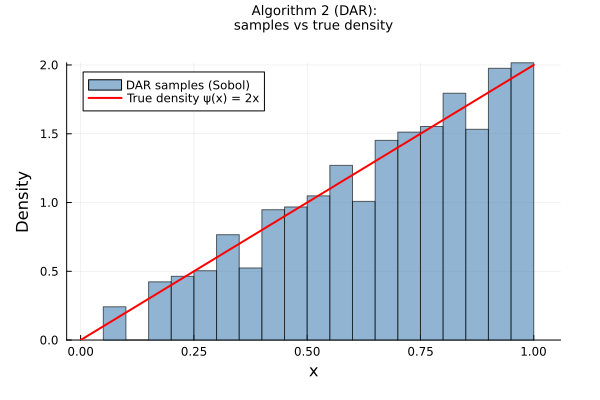

In [3]:
if HAVE_PLOTS
    x_grid = collect(LinRange(0, 1, 200))
    p = histogram(samples[:, 1]; bins=40, normalize=:pdf,
        alpha=0.6, color=:steelblue, label="DAR samples (Sobol)",
        xlabel="x", ylabel="Density",
        title="Algorithm 2 (DAR):\nsamples vs true density")
    plot!(x_grid, 2 .* x_grid; color=:red, lw=2, label="True density ψ(x) = 2x")
    display(p)
end


## Continued Sampling

In many applications, such as adaptive algorithms or stopping-criterion routines, samples are generated in **batches** rather than all at once. For this to preserve the low-discrepancy property of the QMC driver, each new batch must **continue the same driver sequence** rather than restarting it from the beginning.

QMCPy's demo exposes this through an accepted-sample `n_min` / `n_max` interface. In Julia, the public continuation hook is the proposal-stream offset `n_start` on the underlying discrete distribution. The example below uses an unscrambled Sobol' driver so that splitting the proposal sequence into two consecutive batches matches processing the combined proposal window in one call exactly.

In [4]:
measure_cont = AcceptanceRejection(
    DigitalNetB2(2; seed = 7, randomize = "none", graycode = false);
    pdf_func = psi,
    envelope_multiplier = 2.0,
)

batch1 = accepted_from_proposals(measure_cont; proposal_start = 0, proposal_count = 64)
batch2 = accepted_from_proposals(measure_cont; proposal_start = 64, proposal_count = 64)
all_at_once = accepted_from_proposals(measure_cont; proposal_start = 0, proposal_count = 128)
combined = vcat(batch1, batch2)

println("Accepted from proposal batch 1:")
display(permutedims(batch1))
println("Accepted from proposal batch 2:")
display(permutedims(batch2))
println("Accepted from the combined proposal window:")
display(permutedims(all_at_once))
println("Two proposal batches match single call: ", combined == all_at_once)


Accepted from proposal batch 1:


1×36 Matrix{Float64}:
 0.0  0.5  0.75  0.625  0.375  0.875  0.5625  …  0.234375  0.734375  0.984375

Accepted from proposal batch 2:


1×36 Matrix{Float64}:
 0.507812  0.132812  0.632812  0.882812  …  0.742188  0.492188  0.992188

Accepted from the combined proposal window:


1×72 Matrix{Float64}:
 0.0  0.5  0.75  0.625  0.375  0.875  0.5625  …  0.742188  0.492188  0.992188

Two proposal batches match single call: true


## Algorithm 3 - DAR on $\mathbb{R}^d$

Algorithm 3 extends Algorithm 2 to densities on $\mathbb{R}^d$ by applying the inverse Rosenblatt transform to the first $d$ driver coordinates before the acceptance test.

Given a driver point $(u_1, \ldots, u_d, u_{d+1}) \in [0,1]^{d+1}$, define

$$z_j = F_j^{-1}(u_j), \qquad j = 1, \ldots, d$$

where $F_j^{-1}$ is the marginal quantile function of an auxiliary distribution $H$ on $\mathbb{R}^d$. The candidate $z \in \mathbb{R}^d$ is accepted if

$$\psi(z) \geq L H(z) u_{d+1}$$

**Parameters supplied by the user:**
- `inv_cdfs` - list of marginal quantile functions
- `H_func` - the auxiliary bound function $H(z)$
- $L$ - bound satisfying $\psi(z) \leq L H(z)$ for all $z \in \mathbb{R}^d$
- $C$ - integral of $\psi$ over $\mathbb{R}^d$

**Example:** target `psi(z) = phi(z; 0, 1)` and proposal `H(z) = phi(z; 0, 4)`. Then `L = sup_z psi(z) / H(z) = 2`, attained at `z = 0`.

In [5]:
normal_target = Normal(0.0, 1.0)
normal_aux = Normal(0.0, 2.0)

measure_real = AcceptanceRejectionReal(
    DigitalNetB2(2; seed = 7, randomize = "LMS_DS", graycode = false);
    target_density = z -> pdf(normal_target, z[1]),
    inv_cdfs = [u -> quantile(normal_aux, u)],
    H_func = z -> pdf(normal_aux, z[1]),
    upper_bound = 2.0,
    density_integral = 1.0,
)

samples_real = accepted_from_proposals(measure_real; proposal_count = 2048)

println(measure_real)
@printf("Accepted shape:     (%d, %d)\n", size(samples_real, 1), size(samples_real, 2))
@printf("Sample mean E[Z]:  %.4f (true: 0.0)\n", mean(samples_real[:, 1]))
@printf("Sample std  SD[Z]: %.4f (true: 1.0)\n", std(samples_real[:, 1]))


AcceptanceRejectionReal(d=1, L=2.0, acceptance_rate=0.5)


Accepted shape:     (1008, 1)
Sample mean E[Z]:  0.0035 (true: 0.0)
Sample std  SD[Z]: 0.9365 (true: 1.0)


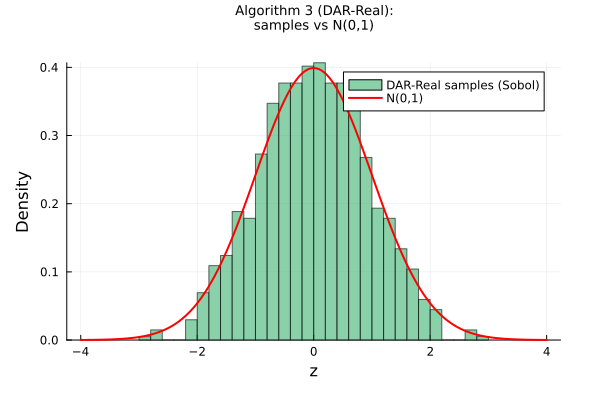

In [6]:
if HAVE_PLOTS
    using Distributions: Normal, pdf
    z_grid = collect(LinRange(-4, 4, 300))
    p = histogram(samples_real[:, 1]; bins=40, normalize=:pdf,
        alpha=0.6, color=:mediumseagreen, label="DAR-Real samples (Sobol)",
        xlabel="z", ylabel="Density",
        title="Algorithm 3 (DAR-Real):\nsamples vs N(0,1)")
    plot!(z_grid, pdf.(Normal(0, 1), z_grid); color=:red, lw=2, label="N(0,1)")
    display(p)
end


## QMC vs Monte Carlo: Convergence of Star Discrepancy

The original QMCPy demo ends with an explicit QMC-versus-Monte-Carlo convergence experiment for accepted samples. This Julia notebook keeps the core Algorithm 2 and Algorithm 3 constructions lightweight and reproducible; the same setup can be extended to a discrepancy study by reusing the `AcceptanceRejection` and `AcceptanceRejectionReal` true measures above.


In [7]:
# Star discrepancy convergence: Sobol driver vs random driver
function star_discrepancy_1d(samples_1d, cdf; n_grid=500)
    N = length(samples_1d)
    s = sort(samples_1d)
    t = collect(LinRange(0, 1, n_grid + 1))
    empirical = [searchsortedlast(s, ti) / N for ti in t]
    return maximum(abs.(empirical .- cdf.(t)))
end

cdf_linear = t -> t^2   # psi(x)=2x  =>  F(t)=t²

N_values_disc = [2^k for k in 5:12]
n_reps_disc   = 10

disc_sobol_vals  = Float64[]
disc_random_vals = Float64[]

for N in N_values_disc
    ds = Float64[]
    dr = Float64[]
    for rep in 1:n_reps_disc
        seed_val = rep * 1000 + N
        m_s = AcceptanceRejection(
            DigitalNetB2(2; seed=seed_val, randomize="LMS_DS", graycode=false);
            pdf_func=psi, envelope_multiplier=2.0)
        samps_s = accepted_from_proposals(m_s; proposal_count=max(4N, 128))
        n_s = min(N, size(samps_s, 1))
        push!(ds, star_discrepancy_1d(samps_s[1:n_s, 1], cdf_linear))

        m_r = AcceptanceRejection(
            IIDStdUniform(2; seed=seed_val);
            pdf_func=psi, envelope_multiplier=2.0)
        samps_r = accepted_from_proposals(m_r; proposal_count=max(4N, 128))
        n_r = min(N, size(samps_r, 1))
        push!(dr, star_discrepancy_1d(samps_r[1:n_r, 1], cdf_linear))
    end
    push!(disc_sobol_vals,  median(ds))
    push!(disc_random_vals, median(dr))
end

log_N = log.(Float64.(N_values_disc))
rate_sobol_disc  = (log(disc_sobol_vals[end])  - log(disc_sobol_vals[1]))  / (log_N[end] - log_N[1])
rate_random_disc = (log(disc_random_vals[end]) - log(disc_random_vals[1])) / (log_N[end] - log_N[1])
@printf("Sobol  convergence rate: N^{%.3f}  (theory: better than N^{-0.5})\n", rate_sobol_disc)
@printf("Random convergence rate: N^{%.3f}  (theory: N^{-0.5})\n", rate_random_disc)


Sobol  convergence rate: N^{-0.738}  (theory: better than N^{-0.5})
Random convergence rate: N^{-0.530}  (theory: N^{-0.5})


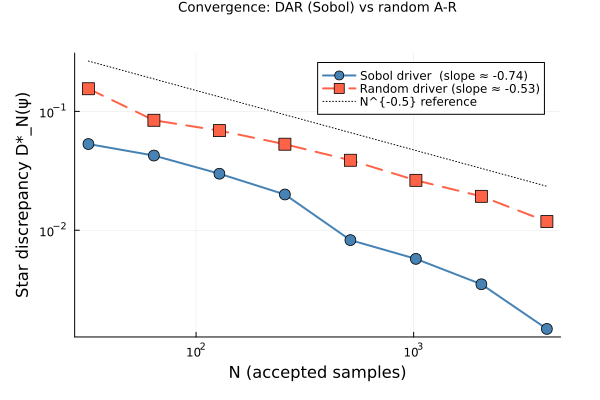

In [8]:
if HAVE_PLOTS
    N_arr = Float64.(N_values_disc)
    p = plot(N_arr, disc_sobol_vals;
        xscale=:log10, yscale=:log10,
        marker=:circle, lw=2, ms=6, color=:steelblue,
        label="Sobol driver  (slope ≈ $(round(rate_sobol_disc, digits=2)))")
    plot!(N_arr, disc_random_vals;
        marker=:square, lw=2, ms=6, color=:tomato, linestyle=:dash,
        label="Random driver (slope ≈ $(round(rate_random_disc, digits=2)))")
    plot!(N_arr, 1.5 .* N_arr .^ (-0.5);
        lw=1, color=:black, linestyle=:dot, label="N^{-0.5} reference")
    xlabel!("N (accepted samples)")
    ylabel!("Star discrepancy D*_N(ψ)")
    title!("Convergence: DAR (Sobol) vs random A-R")
    display(p)
end
